# CT 1 Runthrough

## Q1

### Phase 1: $0 \leq t \leq T$ 
#### $$ \frac{dv}{dt} = \frac{v_{rel}\alpha - \gamma v}{2m_0 - \alpha t}  $$
### Phase 2: $ T \leq t \leq 2T $
#### $$ \frac{dv}{dt} = - \frac{\gamma v}{m_0}  $$

In [522]:
import numpy as np
import matplotlib.pyplot as plt

In [523]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller_rk4(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys



In [524]:
m0 = 1.0
v_rel = 1.0
alpha = 1.0 
gamma = np.asarray([0,alpha/2,alpha])
T = m0/alpha

def f1(t,v):
    if 0<=t<=T:
        return (v_rel*alpha - gamma[0]*v)/(2*m0 - alpha*t)
    else:
        if T<=t<=2*T:
            return - gamma[0]*v/m0


def f2(t,v):
    if 0<=t<=T:
        return (v_rel*alpha - gamma[1]*v)/(2*m0 - alpha*t)
    else:
        if T<=t<=2*T:
            return - gamma[1]*v/m0


def f3(t,v):
    if 0<=t<=T:
        return (v_rel*alpha - gamma[2]*v)/(2*m0 - alpha*t)
    else:
        if T<=t<=2*T:
            return - gamma[2]*v/m0

    

# Step size and initial x-value
h = 1.0e-3
t0 = 0.0
tf= 2*T
v0=0.0

# Generate the array of x-values, equivalent to Julia's range(x0, step=h, length=N)
ts = np.arange(t0, tf, h)  # [x0, x0+h, x0+2h, ..., x0+(N-1)*h]
N=len(ts)

y_ini= np.asarray([0.0])  

# Compute y-values using position-only RK4
ysrk41 = caller_rk4(rk4, f1, y_ini,N,ts,h)
ysrk42 = caller_rk4(rk4, f2, y_ini,N,ts,h)
ysrk43 = caller_rk4(rk4, f3, y_ini,N,ts,h)
#ys_exact1 = fexact1(ts)

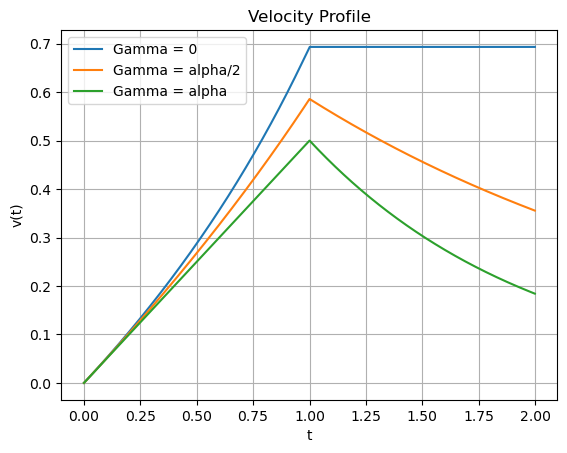

In [525]:
plt.plot(ts, ysrk41[:,0], label='Gamma = 0')
plt.plot(ts, ysrk42[:,0], label='Gamma = alpha/2')
plt.plot(ts, ysrk43[:,0], label='Gamma = alpha')
#plt.plot(ts, ys_exact1, label="Analytical solution", linestyle="--")
plt.title("Velocity Profile")
plt.xlabel("t")
plt.ylabel("v(t)")
plt.grid()
plt.legend()
plt.show()


## Q2

In [527]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller_rk4(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys


def func(t,v):
    return (vT - v)/tau

def exact(xs):
    v = np.zeros(len(xs))
    for i in range(len(xs)):
        v[i]= vT*(1-np.exp(-xs[i]/tau))
    return v

In [528]:
h = 1.0e-3
t0 = 0.0
tf=15.0
v0=0.0
vT = 0.0215
tau = 0.00262

# Generate the array of x-values, equivalent to Julia's range(x0, step=h, length=N)
xs = np.arange(t0, tf, h)  # [x0, x0+h, x0+2h, ..., x0+(N-1)*h]
N=len(xs)

y_ini=np.asarray([0.0])   

# Compute y-values using position-only RK4
ysrk4=caller_rk4(rk4, func, y_ini,N,xs,h)
yexact = exact(xs)

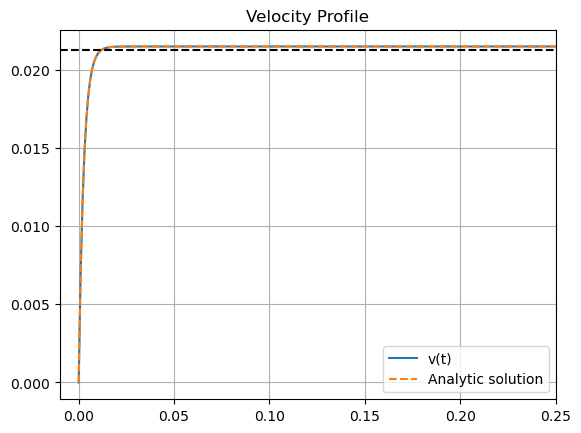

In [529]:
plt.plot(xs, ysrk4[:,0],label="v(t)")
plt.plot(xs, yexact, label="Analytic solution",linestyle="--")
plt.title("Velocity Profile")
plt.xlim(-1.0e-2,0.25)
plt.axhline(y = 0.99*vT, color = "k", ls = "--")
plt.grid()
plt.legend()

In [530]:
eps = 1.0e-4
maxiter = 50

def v(t):
    return vT*(1-np.exp(-t/tau))

def root(t):
    return (v(t) - 0.99*vT)

def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c, iteration


print(f"t*_num {bisection(root,-1.0e-2, 0.05, eps, maxiter)}") 

t*_num (0.0125, 3)


In [531]:
def trapezoid(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(2*np.sum(f(x)) - f(x[0]) - f(x[-1]))/2)

print(f"Using Trapezoid Method --> {trapezoid(v,0,0.012,5)}")


Using Trapezoid Method --> 0.0002012763247783774


## Q3

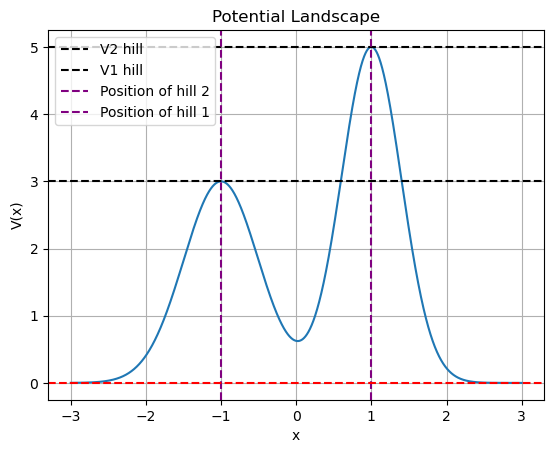

In [533]:
def potential(x):
    V1 = v1*np.exp(-((x+b)**2)/(2*(sigma1**2)))
    V2 = v2*np.exp(-((x-b)**2)/(2*(sigma2**2)))
    return V1+V2

t0 = -3
tf = 3
b = 1.0
sigma1 = 0.5
sigma2 = 0.4
v1 = 3
v2 = 5
h = 1.0e-3
xs = np.arange(t0, tf, h)


plt.plot(xs,potential(xs))
plt.axhline(y = 3, color = "black", ls = "--", label = "V2 hill")
plt.axhline(y = 5, color = "black", ls = "--", label = "V1 hill")
plt.axvline(x = -1, color = "purple", ls = "--", label="Position of hill 2")
plt.axvline(x=1, color = "purple", ls = "--", label = "Position of hill 1")
plt.axhline(y = 0, color = "red", ls = "--")
plt.title("Potential Landscape")
plt.ylabel("V(x)")
plt.xlabel("x")
plt.legend()
plt.grid()

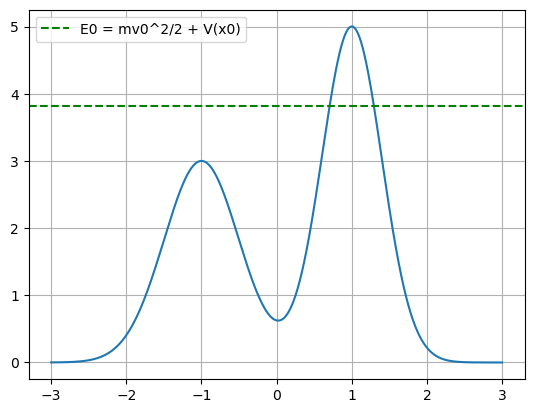

In [534]:

m = 1
v0 = 2
x0 = -0.5
Vx0 = potential(x0)
E0 = 0.5*m*(v0)**2 + Vx0

plt.plot(xs,potential(xs))
plt.axhline(y = E0,  color = "green", ls = "--", label = "E0 = mv0^2/2 + V(x0)")
plt.grid()
plt.legend()

$$ \frac{dx}{dt} = v $$
$$ \frac{dv}{dt} = \frac{1}{m}\left[-\frac{dV}{dx} - \gamma v \right] $$

In [636]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller_rk4(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

gamma = 0.3

def force(x):
    F1 = v1*(x+b)*np.exp(-((x+b)**2)/(2*(sigma1**2)))/(sigma1**2)
    F2 = v2*(x-b)*np.exp(-((x-b)**2)/(2*(sigma2**2)))/(sigma2**2)
    return F1+F2

def f(t,y):
    return np.asarray([y[1], force(y[0]) - gamma*y[1]])
    
h = 1.0e-3
t0 = 0.0
tf= 30.0
x0 = - 0.5
v0 = 2
y_ini=np.asarray([x0,v0])
xs=np.arange(t0,tf,h)
N=len(xs)

ysrk4=caller_rk4(rk4, f, y_ini,N,xs,h)

Text(0, 0.5, 'v(t)')

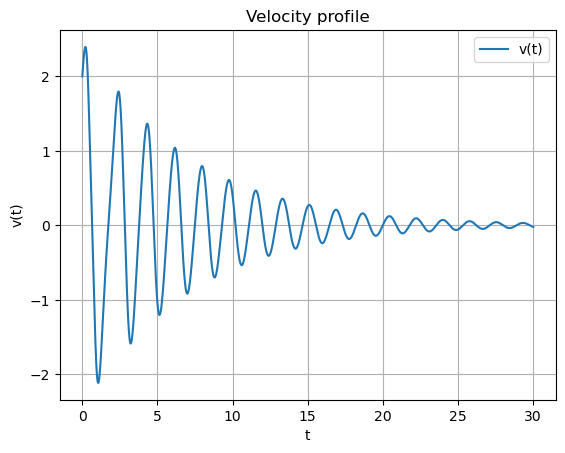

In [537]:
plt.plot(xs,ysrk4[:,1],label= "v(t)")
#plt.axhline(y = 0, color = "k")
plt.grid()
plt.legend()
plt.title("Velocity profile")
plt.xlabel("t")
plt.ylabel("v(t)")

Text(0, 0.5, 'v(t)')

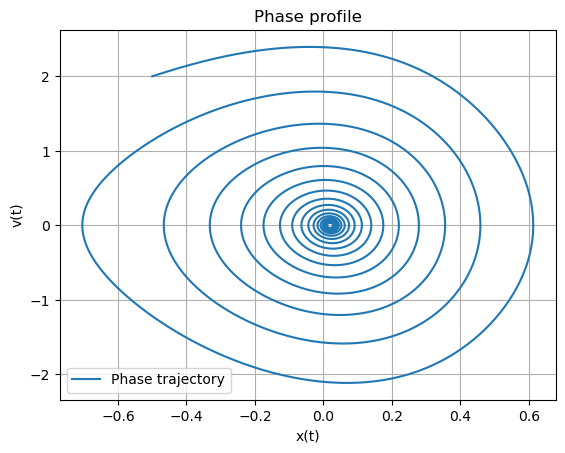

In [538]:
plt.plot(ysrk4[:,0],ysrk4[:,1],label= "Phase trajectory")
plt.legend()
plt.grid()
plt.title("Phase profile")
plt.xlabel("x(t)")
plt.ylabel("v(t)")

In [539]:
#Turning Points
v = ysrk4[:,1]
x = ysrk4[:,0]
bracket=[]
for i in range(len(xs)-1):
    if v[i]*v[i+1]<0:
        if x[i]>0:
            ta = xs[i]
            tb = xs[i+1]
            bracket.append((ta,tb))
print("Three turning points on the right wall")
print(bracket[:3])

Three turning points on the right wall
[(0.643, 0.644), (2.825, 2.826), (4.741, 4.742)]


In [540]:
def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c, iteration


def position_t(t):
    return np.interp(t, xs, ysrk4[:,0])

def velocity_t(t):
    return np.interp(t, xs, ysrk4[:,1])
    
eps = 1.0E-05
maxiter = 50
print(f"The root and number of iteration using Bisection method is {bisection(position_t,0.643, 0.644, eps, maxiter)}") 
print(f"The root and number of iteration using Bisection method is {bisection(velocity_t, 2.825, 2.826, eps, maxiter)}") 
print(f"The root and number of iteration using Bisection method is {bisection(velocity_t, 4.741, 4.742, eps, maxiter)}") 


Bad interval!
The root and number of iteration using Bisection method is None
The root and number of iteration using Bisection method is (2.825734375, 6)
The root and number of iteration using Bisection method is (4.741476562500001, 7)


Text(0, 0.5, 'v(t)')

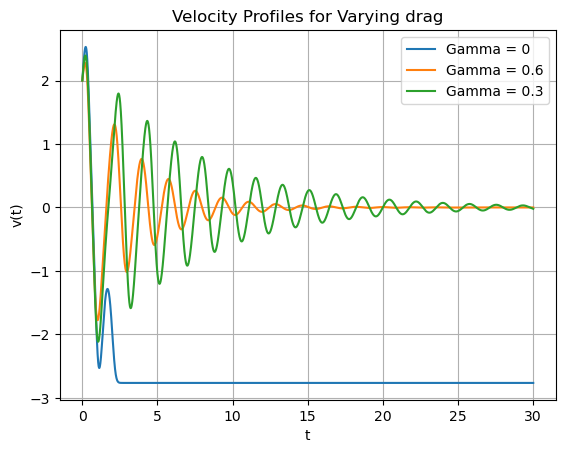

In [541]:
gamma1 = 0
gamma2 = 0.6

def f1(t,y):
    return np.asarray([y[1], force(y[0]) - gamma1*y[1]])

def f2(t,y):
    return np.asarray([y[1], force(y[0]) - gamma2*y[1]])
    

ysrk41=caller_rk4(rk4, f1, y_ini,N,xs,h)
ysrk42 = caller_rk4(rk4, f2, y_ini, N, xs, h)
plt.plot(xs, ysrk41[:,1], label = "Gamma = 0")
plt.plot(xs, ysrk42[:,1], label = "Gamma = 0.6")
plt.plot(xs, ysrk4[:,1], label = "Gamma = 0.3")
plt.legend()
plt.grid()
plt.title("Velocity Profiles for Varying drag")
plt.xlabel("t")
plt.ylabel("v(t)")

Text(0, 0.5, 'v(t)')

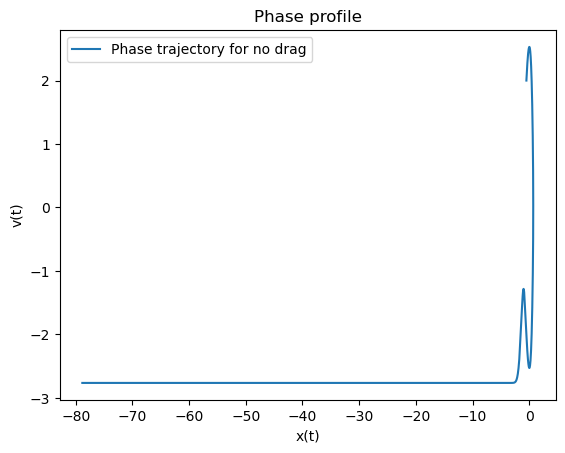

In [542]:
plt.plot(ysrk41[:,0],ysrk41[:,1],label= "Phase trajectory for no drag")
plt.legend()
plt.title("Phase profile")
plt.xlabel("x(t)")
plt.ylabel("v(t)")

## Q4

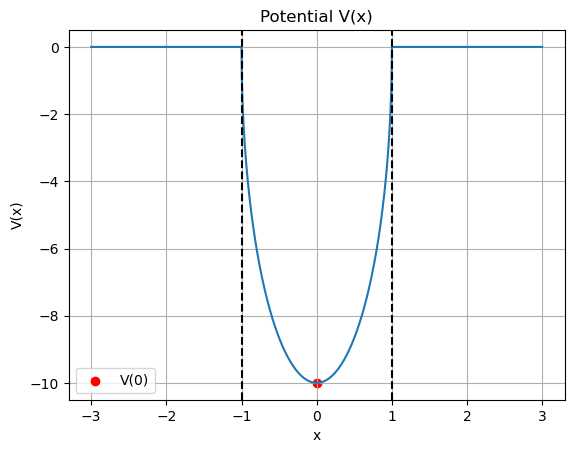

In [544]:
a = 1
V0 = 10

# The potential
def pot(x):
    V = np.zeros_like(x)
    mask = (abs(x)<=a)
    V[mask] = -V0*np.sqrt(a**2 - x[mask]**2)
    return V

t0 = -3
tf = 3
h = 1.0e-3
xs = np.arange(t0,tf,h)
V = pot(xs)
x0 = 0
Vx0 = pot(np.array([x0]))[0]
plt.plot(xs, V)
plt.title("Potential V(x)")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.scatter(x0,Vx0,color="red",label="V(0)")
plt.axvline(x=1, color = "k", ls = "--")
plt.axvline(x = -1, color = "k", ls="--")
plt.legend()
plt.grid()

In [545]:
#RK4 and caller-RK4 functions solve the differential equation using initial conditions y(a) and y'(a)(guessed) and finds solution for other point y(b).
#It's like shooting a projectile with known starting position and slope and guessing where it lands. 

# The following is standard RK4. It calls a function f(x,y,k) where k is a paramter
def rk4(f,x,y,k,h):
    k1 = h*f(x,y,k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1+2*k2+2*k3+k4)/6

# The following is a caller function. It integrates f from xlim[0] to xlim[1] with initial condition yini. 
# The parameter k is included in the argument along with the number of points N.
def caller_rk4(f,xlim,yini,k,N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N,len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

def odefun2(x,y,E):
    k2 = E - pot(x);
    return np.array([y[1], -k2 * y[0]]) 



# This is an implementation of the secant method used for finding the root of the function score. 
#It finds the root for score(E)=0. It keeps updating roots until |score|<tolerance. 
def secant(ks,f,method,ybound):
    k1, k2 = ks
    iter = 0
    while abs(method(k2,f,ybound))>tol and iter<maxiter:
        f1 = method(k1,f,ybound)
        f2 = method(k2,f,ybound)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
        print(iter, k1, k2, method(k2,f,ybound))
    if iter == maxiter:
        return iter, None
    else:
        return iter, k2

In [546]:
#The score function evaluates how far the solution is from satisfying psi(x_max)=0
# The score. Note: we are integrating from the right and from the left and checking the difference at one of the turning points.
def score2(E,f,ybound):
    # Start from the left
    yini1 = (ybound[0], 1.0e-2);
    # psi_<
    xs1, ys1 = caller_rk4(odefun2,xlim,yini1,E,N)
    a = abs(xs1 + Lo/2);
    # find solution at x = 1/2 (left turning point)
    n1=np.where(a == np.min(a))[0][0]
    # Start from right
    yini2 = (ybound[1], 1.0e-2)
    # psi_>
    xs2, ys2 = caller_rk4(odefun2,xlim[-1::-1],yini2,E,N)
    a = abs(xs2 + Lo/2);
    # find solution at x = 1/2 (right turning point)
    n2=np.where(a == np.min(a))[0][0]
    # scale psi_>
    ys2 = ys1[n1][0]*ys2/ys2[n2][0]
    # return the difference of derivatives as score
    #mismatch function F(E)
    return ys1[n1][1] - ys2[n2][1]


Lo = 1.0
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
yini = (ybound[0], 0.1) 
N = 129
maxiter = 50
tol = 1.0e-5

In [547]:
#Plotting mismatch function F(E) over E
Es = np.linspace(-Vo, 0, 1000);
scores = [score2(E, odefun2, ybound) for E in Es];

Text(0, 0.5, 'Score')

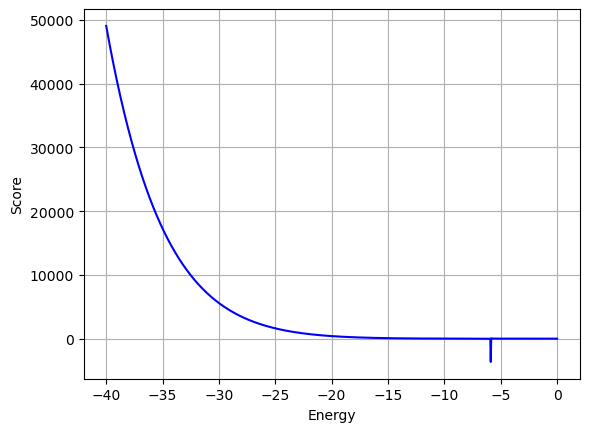

In [548]:
plt.plot(Es,scores,'b-')
plt.grid()
plt.xlabel("Energy")
plt.ylabel("Score")

(-8.0, -7.0)

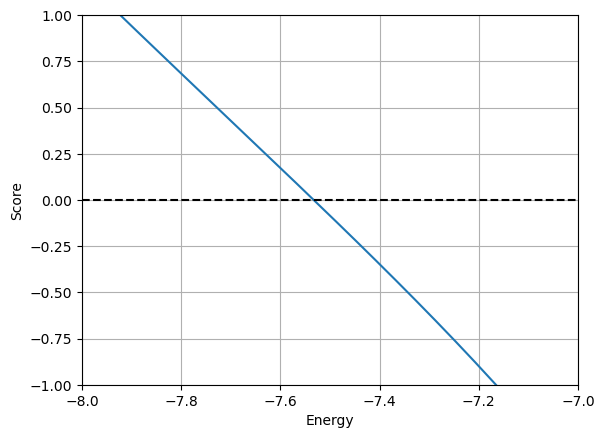

In [549]:
plt.plot(Es,scores)
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy");
plt.ylabel("Score");
plt.ylim([-1,1])
plt.xlim([-8.0,-7.0])

In [550]:
Eini=(-7.6,-7.4)
eps = 1.0E-06
maxiter = 100
def f(E):
    return score2(E, odefun2, ybound)
    
Eeigen1, iter = bisection(f, Eini[0],Eini[1],eps,maxiter)
print(Eeigen1)

-7.532640838623048


Text(0, 0.5, '$\\psi$')

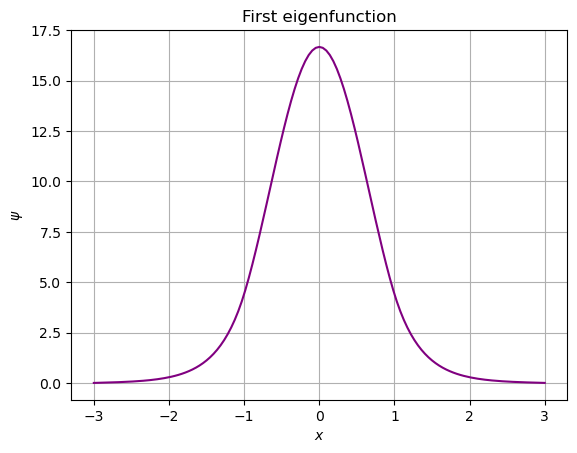

In [551]:
xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen1, N);
y1 = [y[0] for y in ys];
plt.plot(xs, y1,color="purple")
plt.title("First eigenfunction")
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")

In [552]:
if f(Eeigen1)<=1.0e-6:
    print("Yes eigenvalue verified")
else:
    print("Check again")

Yes eigenvalue verified


(-3.0, -2.0)

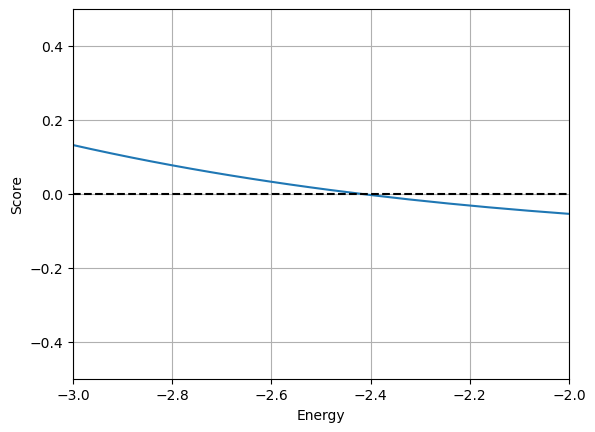

In [553]:
plt.plot(Es,scores)
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel("Energy");
plt.ylabel("Score");
plt.ylim([-0.5,0.5])
plt.xlim([-3.0,-2.0])

In [554]:
Eini=(-2.6,-2.2)
    
Eeigen2, iter = bisection(f, Eini[0],Eini[1],eps,maxiter)
print(Eeigen2)

-2.4185791015625004


Text(0, 0.5, '$\\psi$')

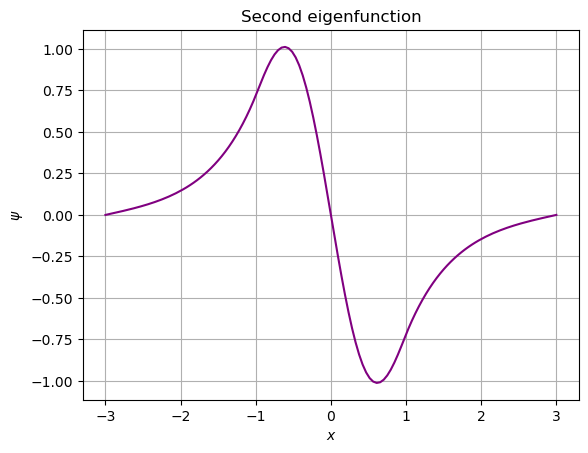

In [555]:
xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen2, N);
y1 = [y[0] for y in ys];
plt.plot(xs, y1,color="purple")
plt.title("Second eigenfunction")
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")

In [556]:
if f(Eeigen2)<=1.0e-6:
    print("Yes eigenvalue verified")
else:
    print("Check again")


Yes eigenvalue verified


Text(0.5, 1.0, 'Normalized first eigenfunction')

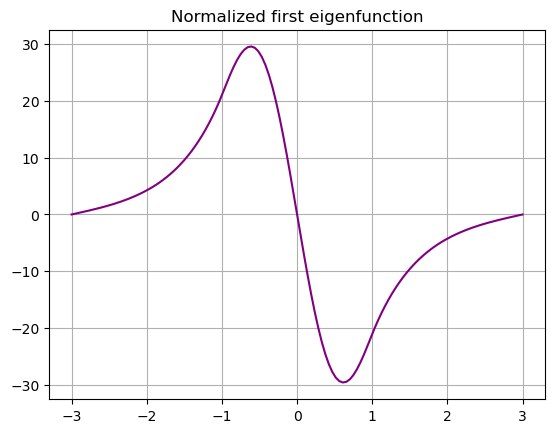

In [557]:
def trapezoid_norm(y, h):
    store = y[0]**2 + y[-1]**2
    
    for i in range(1, len(y)-1):
        store += 2 * y[i]**2
        
    return (h/2) * store

normfact = trapezoid_norm(y1,h)
y1 = y1/normfact
plt.plot(xs, y1,color="purple")
plt.grid()
plt.title("Normalized first eigenfunction")

Text(0.5, 1.0, 'Normalized 2nd eigenfunction')

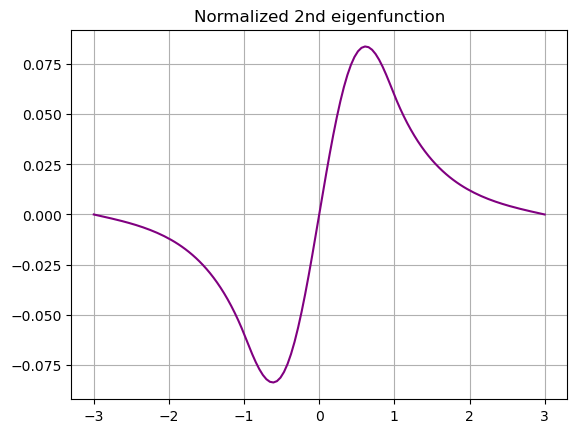

In [558]:
def trapezoid_norm(y, h):
    store = y[0]**2 + y[-1]**2
    
    for i in range(1, len(y)-1):
        store += 2 * y[i]**2
        
    return (h/2) * store

normfact = trapezoid_norm(y1,h)
y2 = y2/normfact
plt.plot(xs, y2,color="purple")
plt.grid()
plt.title("Normalized 2nd eigenfunction")

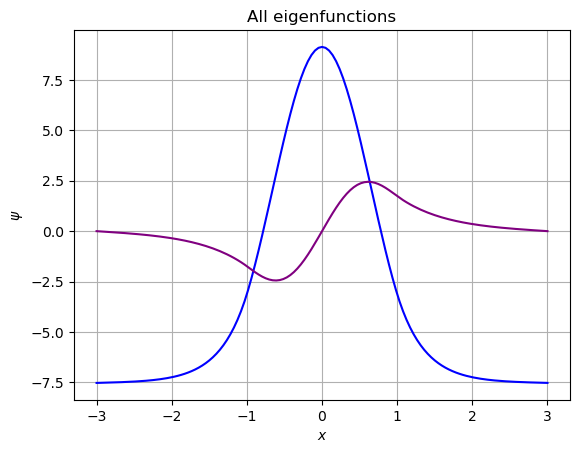

In [559]:
xs, ys1 = caller_rk4(odefun2, xlim, yini, Eeigen1, N);
y1 = [y[0]+Eeigen1 for y in ys1];
plt.plot(xs, y1,color="b")
plt.title("First eigenfunction")
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")

xs, ys2 = caller_rk4(odefun2, xlim, yini, Eeigen2, N);
y2 = [y[0]*+Eeigen2 for y in ys2];
plt.plot(xs, y2,color="purple")
plt.title("All eigenfunctions")
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")
plt.grid()

# Endsem 2025 Paper solving

## Q1

C:\Users\arany\AppData\Local\Temp\ipykernel_27036\3646958002.py:2: RuntimeWarning: divide by zero encountered in divide
  return 2/x**4 - 1/x**2
C:\Users\arany\AppData\Local\Temp\ipykernel_27036\3646958002.py:2: RuntimeWarning: invalid value encountered in subtract
  return 2/x**4 - 1/x**2


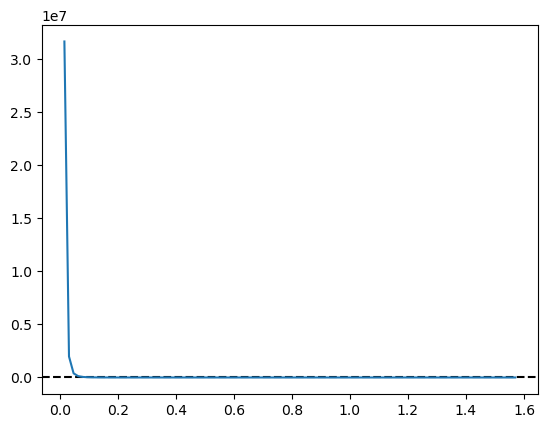

The root and number of iteration using Newton-Raphson method is (1.414213562325828, 7, -4.7267079139601265e-11)


In [562]:
def f(x):
    return 2/x**4 - 1/x**2
    
def f_prime(x):
    return -8/x**5 + 2/x**3
    
#plotting the function on the graph
x = np.linspace(0,1.57,100)
plt.axhline(y = 0, color = "k", ls = "--")
plt.plot(x,f(x))
plt.show()

#defining our error margin and maximum iterations
eps = 1.0E-08
maxiter = 100


   



def newton(f,x1,eps,maxiter):
    #f: function whose roots we are to find
    #x1: starting point
    x2 = x1
    iteration = 1
    while abs(f(x2)) >= eps and iteration < maxiter:
        x2 = x1 - (f(x1)/f_prime(x1))
        x1 = x2
        iteration += 1
        
    if iteration == maxiter and abs(f(x2)) >= eps:
        print("Failed to converge!")
        return None
    else:
        dev = x2 - np.sqrt(2)
        return x2, iteration, dev
print(f"The root and number of iteration using Newton-Raphson method is {newton(f,1.0,eps,maxiter)}") 


In [563]:
print(f"The root and number of iteration using Newton-Raphson method is {newton(f,2.5,eps,maxiter)}") 


The root and number of iteration using Newton-Raphson method is (11388.02457638685, 21, 11386.610362824476)


## Q2

### $$\frac{dy}{dt} = v_y $$
### $$\frac{dv_y}{dt} = - \omega^2 y - \lambda v_y^5  $$

In [566]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller_rk4(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

w = np.pi*4
lamda = 2

def funct(t,y):
    return np.asarray([y[1], - (w**2)*y[0] - lamda*(y[1]**5)])
    
h = 1.0e-3
t0 = 0.0
tf= 2.0
y_ini=np.asarray([1.0,0.0])
xs=np.arange(t0,tf,h)
N=len(xs)

ysrk4=caller_rk4(rk4, funct, y_ini,N,xs,h)

Text(0, 0.5, 'y(t)')

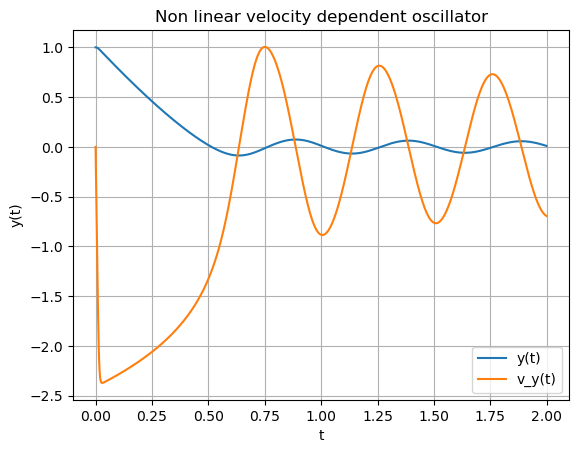

In [567]:
plt.plot(xs,ysrk4[:,0],label= "y(t)")
plt.plot(xs,ysrk4[:,1],label= "v_y(t)")

#plt.axhline(y = 0, color = "k",linestyle="--")
plt.grid()
plt.legend()
plt.title("Non linear velocity dependent oscillator")
plt.xlabel("t")
plt.ylabel("y(t)")

In [568]:
def position(t):
    return np.interp(t, ts, ysrk4[:,0])

def velocity(t):
    return np.interp(t, ts, ysrk4[:,1])


eps = 1.0E-05
maxiter = 100

def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c, iteration

print(f"The first root using Bisection method is {bisection(position,0.50,0.70, eps, maxiter)}") 
print(f"The second root using Bisection method is {bisection(position,0.70,0.85, eps, maxiter)}") 
print(f"The third root using Bisection method is {bisection(position,0.86,1.20, eps, maxiter)}") 
print(f"The fourth root using Bisection method is {bisection(position,1.15,1.35, eps, maxiter)}") 
print(f"The fifth root using Bisection method is {bisection(position,1.35,1.55, eps, maxiter)}") 
print(f"The sixth root using Bisection method is {bisection(position,1.56,1.85, eps, maxiter)}") 


The first root using Bisection method is (0.51402587890625, 14)
The second root using Bisection method is (0.7635375976562498, 12)
The third root using Bisection method is (1.0133984375, 9)
The fourth root using Bisection method is (1.2633544921874997, 13)
The fifth root using Bisection method is (1.5133056640625, 13)
The sixth root using Bisection method is (1.7632867431640622, 14)


## Q3

### $$\frac{dy}{dt} = v_y $$
### $$\frac{dv_y}{dt} = - y + 2\frac{v_y^2}{y}  $$

In [571]:
#rk4 function solves the ODE for given x,y(single step)
# The following is standard RK4. It calls a function f(x,y,k) where k is a paramter
def rk4(f,x,y,k,h):
    k1 = h*f(x,y,k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1+2*k2+2*k3+k4)/6

# The following is a caller function. It integrates f from xlim[0] to xlim[1] with initial condition yini. 
# The parameter k is included in the argument along with the number of points N.
#caller_rk4 solves the ODE for the entire interval. Initial condition vector yini = [y  y'] in this case. 
def caller_rk4(f,xlim,yini,k,N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N,len(yini)))  
#In this case, len(yini)=2. ys is therefore an array of shape (N,2)
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)  # ys stores [y  y'] values after each RK4 iteration in every row
    return xs, ys

# The following function calculates the departure from the boundary condition at the other end.
def score(k,f,ybound):
    yini = (ybound[0], k)   # y(0)=0.4, z(0)=k
    xs, ys = caller_rk4(f,xlim,yini,k,N)
    return ys[-1][0] - ybound[1]          # ys[-1] represents last row. ys[-1][0] contains the final y at endpoint and ys[-1][1] contains y' at endpoint
    
# This is an implementation of the secant method used for finding the root of the function score. 
# This function finds roots k such that score(k)=0
def secant(ks,f,method,ybound):
    k1, k2 = ks
    iter = 0
    while abs(method(k2,f,ybound))>tol and iter<maxiter:  # updating root k till |score(k)|<tolerance
        f1 = method(k1,f,ybound)
        f2 = method(k2,f,ybound)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
        print(iter, k1, k2, method(k2,f,ybound))
    if iter == maxiter:
        return iter, None
    else:
        return iter, k2


In [572]:
# define the ODE function
def odefun1(x,y,k):
    return np.array([y[1], -y[0] + 2*(y[1]**2)/y[0]]) 

# Initialization
xlim = (0.0, 2.0)
yini = (0.4, 0.2) # 0.2 is an arbitrary number finally adjusted by normalization

# Boundary condition
ybound = (0.4, 0.2)

# Number of points
N = 129

# Max iteration and tolerance for secant
maxiter = 50
tol = 1.0e-6

C:\Users\arany\AppData\Local\Temp\ipykernel_27036\2793678990.py:3: RuntimeWarning: overflow encountered in scalar power
  return np.array([y[1], -y[0] + 2*(y[1]**2)/y[0]])
C:\Users\arany\AppData\Local\Temp\ipykernel_27036\2793678990.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array([y[1], -y[0] + 2*(y[1]**2)/y[0]])
C:\Users\arany\AppData\Local\Temp\ipykernel_27036\2793678990.py:3: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([y[1], -y[0] + 2*(y[1]**2)/y[0]])


Text(0, 0.5, 'Score')

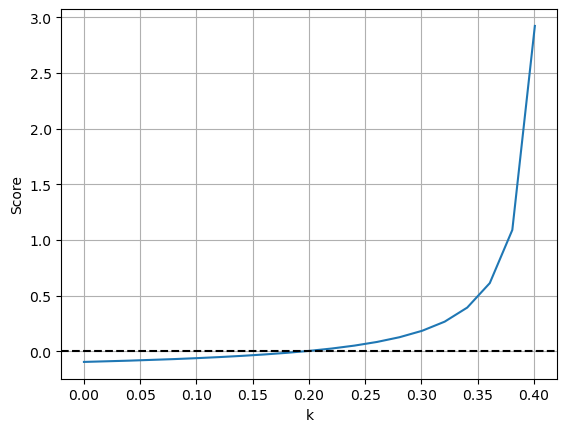

In [573]:
Es = np.linspace(0,10,500)
scores = [score(E,odefun1,ybound) for E in Es]

plt.plot(Es, scores)  # we plot scores vs k so we can track points where score(k)=0. Those k values are eigenvalues. 
plt.grid()
plt.axhline(y=0,color="k",linestyle="--")
plt.xlabel("k")
plt.ylabel("Score")

In [574]:
kini=(0.15,0.25);
iter,keigen = secant(kini,odefun1,score,ybound)  # finding eigenvalue

1 0.25 0.18316024911408996 -0.009655604770884868
2 0.18316024911408996 0.19152644856309223 -0.002527300481661665
3 0.19152644856309223 0.19449263786131102 0.00012992754929913586
4 0.19449263786131102 0.19434760337357246 -1.6617489657366757e-06
5 0.19434760337357246 0.1943494349124071 -1.0788429594121851e-09


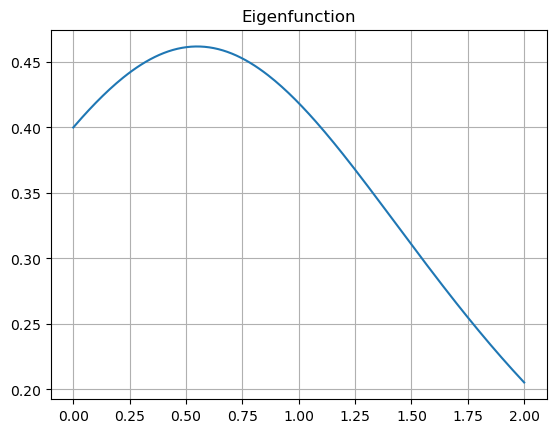

In [575]:
xs, ys = caller_rk4(odefun1,xlim,yini,keigen,200);
h = xs[1]-xs[0]
y1 = [y[0] for y in ys]  #eigenfunction for first eigenvalue

plt.plot(xs,y1)
plt.title("Eigenfunction")
plt.grid()

## Q4

In [577]:
def take_a_step():
    s = np.random.rand()
    if s > 0.5:
        return 1
    else:
        return -1

In [578]:
num_walkers = 100000
num_step = 50

final_positions = np.zeros(num_step+1)
for walker in range(num_walkers):
    pos = 0
    for step in range(num_step):
        pos += take_a_step()
    pos_in_array = int((pos+num_step)/2.0)
    #print(finpos, pos_in_array)
    final_positions[pos_in_array] += 1

positions = np.linspace(-num_step, num_step, num_step+1)

In [579]:
# For plotting the Gaussian curve
x = np.linspace(-50,50,1000)
y = (2/np.sqrt(2*np.pi*50))* np.exp(-x**2/(2*50))

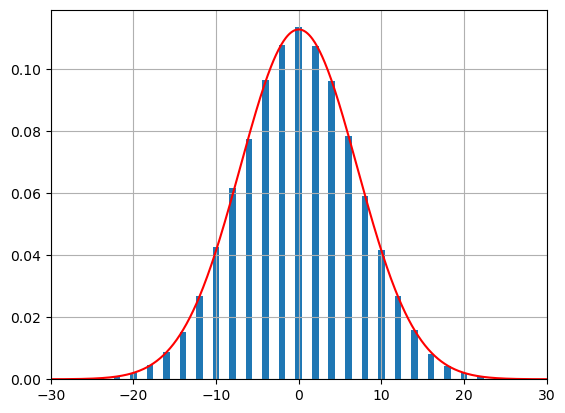

In [580]:
plt.bar(positions, final_positions/num_walkers)
plt.plot(x,y,color="red")
plt.xlim(-30,30)
plt.grid()

In [581]:
num_walkers = 100000
num_steps = 50

positions = np.zeros(num_walkers, dtype=int)
xaverage = np.zeros(num_steps)
for step in range(num_steps):
    xaverage[step] = sum([i**2 for i in positions])/num_walkers
    for walker in range(num_walkers):
        positions[walker] += take_a_step()
    
steps = [i for i in range(num_steps)]

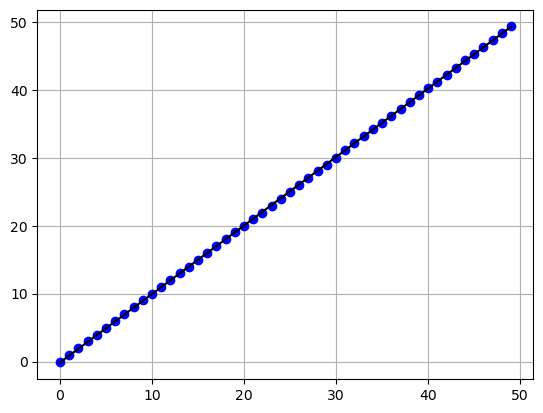

In [582]:
from scipy.optimize import curve_fit


def line(x, m, c):
    return x*m + c

# Fit the data
popt_average, _  = curve_fit(line, steps, xaverage, p0=[1.0, 1.0])

# Generate smooth fit
xfine = np.linspace(steps[0], steps[-1], 1000)
yfine_average = line(xfine, *popt_average)

plt.plot(steps,xaverage,'bo')
plt.plot(xfine, yfine_average, label=f"Euler Fit. Slope = {popt_average[0]:.2f}", color="k")

plt.grid()

In [583]:
xaverage

array([ 0.     ,  1.     ,  1.98804,  2.97456,  3.95616,  4.95888,
        5.97208,  6.9732 ,  7.99848,  9.01328,  9.97368, 10.97672,
       11.98844, 12.98952, 13.97656, 14.96256, 15.96284, 16.9716 ,
       17.98016, 19.0028 , 19.95332, 20.91696, 21.89   , 22.88856,
       23.92344, 24.9768 , 25.94204, 26.95336, 28.00364, 28.98776,
       30.01852, 31.07672, 32.15552, 33.18304, 34.21224, 35.18552,
       36.1398 , 37.14712, 38.21156, 39.22048, 40.27656, 41.19512,
       42.1966 , 43.2748 , 44.3342 , 45.32816, 46.32848, 47.37856,
       48.33676, 49.31472])